# Model Training

### Import libraries

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve,
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import joblib

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

### Define project paths

In [2]:
processed_data_folder = Path("../data/processed")
results_folder = Path("../results")
models_folder = results_folder / "models"
predictions_folder = results_folder / "predictions"
figures_folder = results_folder / "figures"

models_folder.mkdir(parents=True, exist_ok=True)
predictions_folder.mkdir(parents=True, exist_ok=True)
figures_folder.mkdir(parents=True, exist_ok=True)

print("Processed data folder:")
print(processed_data_folder.resolve())

print("\nResults folder:")
print(results_folder.resolve())

Processed data folder:
/Volumes/GraceHardDrive/aml_final_project/data/processed

Results folder:
/Volumes/GraceHardDrive/aml_final_project/results


### Load processed datasets

In [3]:
X_train_clean = pd.read_csv(
    processed_data_folder / "X_train_clean.csv"
)

X_test_clean = pd.read_csv(
    processed_data_folder / "X_test_clean.csv"
)

X_train_standard = pd.read_csv(
    processed_data_folder / "X_train_standard.csv"
)

X_test_standard = pd.read_csv(
    processed_data_folder / "X_test_standard.csv"
)

X_train_minmax = pd.read_csv(
    processed_data_folder / "X_train_minmax.csv"
)

X_test_minmax = pd.read_csv(
    processed_data_folder / "X_test_minmax.csv"
)

y_train = pd.read_csv(
    processed_data_folder / "y_train.csv"
)

y_test = pd.read_csv(
    processed_data_folder / "y_test.csv"
)

### Convert target DataFrames to Series

In [4]:
y_train = y_train.squeeze("columns")
y_test = y_test.squeeze("columns")

print(type(y_train))
print(type(y_test))

<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>


### Confirm dataset shapes

In [5]:
print("X_train_clean:", X_train_clean.shape)
print("X_test_clean:", X_test_clean.shape)

print("X_train_standard:", X_train_standard.shape)
print("X_test_standard:", X_test_standard.shape)

print("X_train_minmax:", X_train_minmax.shape)
print("X_test_minmax:", X_test_minmax.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train_clean: (3390, 15)
X_test_clean: (848, 15)
X_train_standard: (3390, 15)
X_test_standard: (848, 15)
X_train_minmax: (3390, 15)
X_test_minmax: (848, 15)
y_train: (3390,)
y_test: (848,)


### Verify feature alignment

In [6]:
print(
    "Clean columns match:",
    list(X_train_clean.columns) ==
    list(X_test_clean.columns)
)

print(
    "Standard columns match:",
    list(X_train_standard.columns) ==
    list(X_test_standard.columns)
)

print(
    "Min-max columns match:",
    list(X_train_minmax.columns) ==
    list(X_test_minmax.columns)
)

Clean columns match: True
Standard columns match: True
Min-max columns match: True


# Linear Regression

### Train the Linear Regression Model

In [7]:
linear_model = LinearRegression()

linear_model.fit(
    X_train_clean,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Generate Linear Regression predictions

In [8]:
linear_train_predictions = linear_model.predict(
    X_train_clean
)

linear_test_predictions = linear_model.predict(
    X_test_clean
)

In [9]:
linear_test_predictions[:10]

array([0.20535374, 0.23153013, 0.22269821, 0.44440756, 0.22079497,
       0.20281328, 0.23531826, 0.12572672, 0.16295026, 0.16934695])

### Convert Linear Regression output to classes

In [10]:
linear_test_classes = (
    linear_test_predictions >= 0.5
).astype(int)

linear_train_classes = (
    linear_train_predictions >= 0.5
).astype(int)

In [11]:
print(
    "Unique predicted classes:",
    np.unique(linear_test_classes)
)

Unique predicted classes: [0 1]


### Evaluate Linear Regression as a regression model

In [12]:
linear_regression_metrics = {
    "Model": "Linear Regression",
    "MSE": mean_squared_error(
        y_test,
        linear_test_predictions
    ),
    "RMSE": np.sqrt(
        mean_squared_error(
            y_test,
            linear_test_predictions
        )
    ),
    "MAE": mean_absolute_error(
        y_test,
        linear_test_predictions
    ),
    "R2": r2_score(
        y_test,
        linear_test_predictions
    )
}

linear_regression_metrics

{'Model': 'Linear Regression',
 'MSE': 0.121261025441636,
 'RMSE': 0.3482255381812712,
 'MAE': 0.23959749948262016,
 'R2': 0.05985608306991608}

### Evaluate Linear Regression as a classifier

In [13]:
linear_classification_metrics = {
    "Model": "Linear Regression",
    "Accuracy": accuracy_score(
        y_test,
        linear_test_classes
    ),
    "Precision": precision_score(
        y_test,
        linear_test_classes,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        linear_test_classes,
        zero_division=0
    ),
    "F1 Score": f1_score(
        y_test,
        linear_test_classes,
        zero_division=0
    ),
    "ROC AUC": roc_auc_score(
        y_test,
        linear_test_predictions
    )
}

linear_classification_metrics

{'Model': 'Linear Regression',
 'Accuracy': 0.8502358490566038,
 'Precision': 0.6666666666666666,
 'Recall': 0.031007751937984496,
 'F1 Score': 0.05925925925925926,
 'ROC AUC': 0.6951946609740056}

### Linear Regression classification report

In [14]:
print(
    classification_report(
        y_test,
        linear_test_classes,
        target_names=["No CHD", "CHD"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      No CHD       0.85      1.00      0.92       719
         CHD       0.67      0.03      0.06       129

    accuracy                           0.85       848
   macro avg       0.76      0.51      0.49       848
weighted avg       0.82      0.85      0.79       848



### Linear Regression confusion matrix

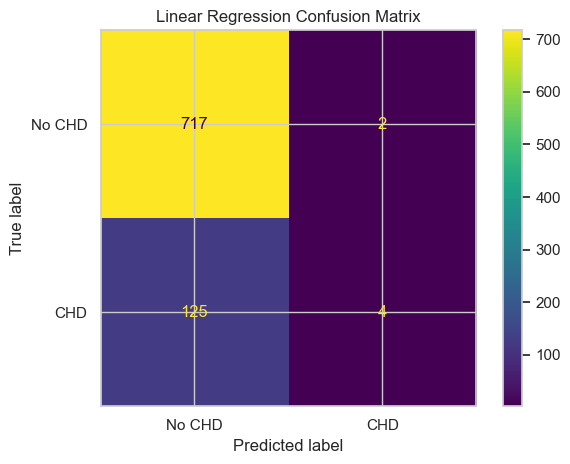

In [15]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    linear_test_classes,
    display_labels=["No CHD", "CHD"]
)

plt.title("Linear Regression Confusion Matrix")
plt.tight_layout()

plt.savefig(
    figures_folder /
    "linear_regression_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Save the Linear Regression model

In [16]:
joblib.dump(
    linear_model,
    models_folder / "linear_regression_model.joblib"
)

['../results/models/linear_regression_model.joblib']

# Logistic Regression

### Train Logistic Regression with standardized data

In [17]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_standard,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

### Generate Logistic Regression predictions

In [18]:
logistic_train_predictions = logistic_model.predict(
    X_train_standard
)

logistic_test_predictions = logistic_model.predict(
    X_test_standard
)

In [19]:
logistic_train_probabilities = (
    logistic_model.predict_proba(
        X_train_standard
    )[:, 1]
)

logistic_test_probabilities = (
    logistic_model.predict_proba(
        X_test_standard
    )[:, 1]
)

### Evaluate Logistic Regression

In [20]:
logistic_metrics = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(
        y_test,
        logistic_test_predictions
    ),
    "Precision": precision_score(
        y_test,
        logistic_test_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        logistic_test_predictions,
        zero_division=0
    ),
    "F1 Score": f1_score(
        y_test,
        logistic_test_predictions,
        zero_division=0
    ),
    "ROC AUC": roc_auc_score(
        y_test,
        logistic_test_probabilities
    )
}

logistic_metrics

{'Model': 'Logistic Regression',
 'Accuracy': 0.8490566037735849,
 'Precision': 0.5294117647058824,
 'Recall': 0.06976744186046512,
 'F1 Score': 0.1232876712328767,
 'ROC AUC': 0.6996366615993359}

### Logistic Regression classification report

In [21]:
print(
    classification_report(
        y_test,
        logistic_test_predictions,
        target_names=["No CHD", "CHD"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      No CHD       0.86      0.99      0.92       719
         CHD       0.53      0.07      0.12       129

    accuracy                           0.85       848
   macro avg       0.69      0.53      0.52       848
weighted avg       0.81      0.85      0.80       848



### Logistic Regression confusion matrix

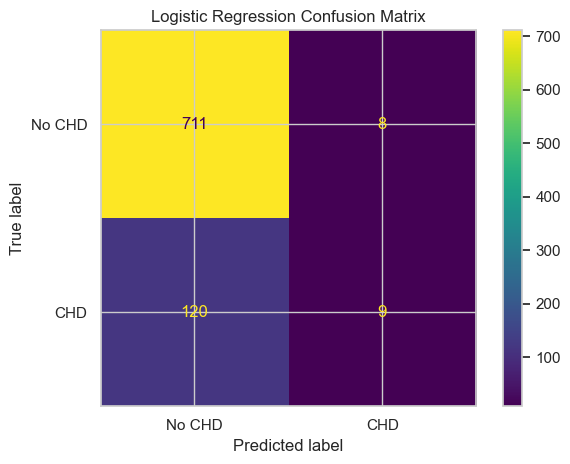

In [22]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_test_predictions,
    display_labels=["No CHD", "CHD"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()

plt.savefig(
    figures_folder /
    "logistic_regression_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Examine Logistic Regression coefficients

In [23]:
logistic_coefficients = pd.DataFrame({
    "Feature": X_train_standard.columns,
    "Coefficient": logistic_model.coef_[0],
    "Odds Ratio": np.exp(logistic_model.coef_[0])
})

logistic_coefficients = (
    logistic_coefficients
    .sort_values(
        by="Coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

logistic_coefficients

,Feature,Coefficient,Odds Ratio
0,prevalentStroke,0.834893,2.304567
1,age,0.572034,1.771867
2,male,0.452382,1.572052
3,BPMeds,0.334118,1.396708
4,sysBP,0.323828,1.382409
5,cigsPerDay,0.315410,1.370821
6,prevalentHyp,0.175009,1.191257
7,glucose,0.165155,1.179575
8,diabetes,0.126584,1.134945
9,totChol,0.098663,1.103695


### Plot Logistic Regression coefficients

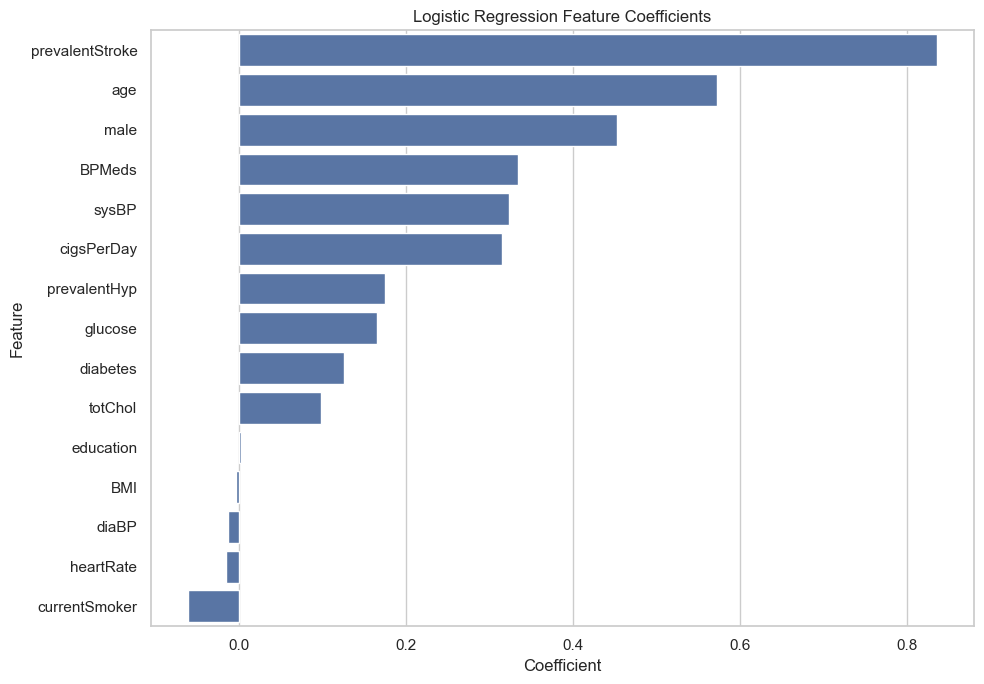

In [24]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=logistic_coefficients,
    x="Coefficient",
    y="Feature"
)

plt.title("Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(
    figures_folder /
    "logistic_regression_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Save Logistic Regression outputs

In [25]:
joblib.dump(
    logistic_model,
    models_folder /
    "logistic_regression_model.joblib"
)

logistic_coefficients.to_csv(
    results_folder /
    "logistic_regression_coefficients.csv",
    index=False
)

# K-Nearest Neighbors

### Train a baseline KNN model

In [26]:
knn_baseline = KNeighborsClassifier(
    n_neighbors=5
)

knn_baseline.fit(
    X_train_standard,
    y_train
)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


### Generate baseline KNN predictors

In [27]:
knn_baseline_predictions = (
    knn_baseline.predict(
        X_test_standard
    )
)

knn_baseline_probabilities = (
    knn_baseline.predict_proba(
        X_test_standard
    )[:, 1]
)

### Evaluate baseline KNN

In [28]:
knn_baseline_metrics = {
    "Model": "KNN Baseline",
    "Accuracy": accuracy_score(
        y_test,
        knn_baseline_predictions
    ),
    "Precision": precision_score(
        y_test,
        knn_baseline_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        knn_baseline_predictions,
        zero_division=0
    ),
    "F1 Score": f1_score(
        y_test,
        knn_baseline_predictions,
        zero_division=0
    ),
    "ROC AUC": roc_auc_score(
        y_test,
        knn_baseline_probabilities
    )
}

knn_baseline_metrics

{'Model': 'KNN Baseline',
 'Accuracy': 0.8408018867924528,
 'Precision': 0.375,
 'Recall': 0.06976744186046512,
 'F1 Score': 0.11764705882352941,
 'ROC AUC': 0.5713361581007214}

### Tune KNN using GridSearchCV

In [29]:
knn_parameter_grid = {
    "n_neighbors": list(range(3, 32, 2)),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

In [30]:
stratified_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [31]:
knn_grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=knn_parameter_grid,
    scoring="roc_auc",
    cv=stratified_cv,
    n_jobs=-1,
    return_train_score=True
)

knn_grid_search.fit(
    X_train_standard,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and para

### View best KNN parameters

In [32]:
print(
    "Best parameters:",
    knn_grid_search.best_params_
)

print(
    "Best cross-validation ROC AUC:",
    round(
        knn_grid_search.best_score_,
        4
    )
)

Best parameters: {'metric': 'euclidean', 'n_neighbors': 31, 'weights': 'distance'}
Best cross-validation ROC AUC: 0.6919


### Save all KNN tuning results

In [33]:
knn_cv_results = pd.DataFrame(
    knn_grid_search.cv_results_
)

knn_cv_results = knn_cv_results[
    [
        "param_n_neighbors",
        "param_weights",
        "param_metric",
        "mean_train_score",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values(
    by="rank_test_score"
)

knn_cv_results.head(10)

,param_n_neighbors,param_weights,param_metric,mean_train_score,mean_test_score,std_test_score,rank_test_score
29,31,distance,euclidean,1.000000,0.691919,0.021103,1
28,31,uniform,euclidean,0.773168,0.691314,0.020868,2
53,25,distance,manhattan,1.000000,0.688361,0.019706,3
27,29,distance,euclidean,1.000000,0.687416,0.021296,4
55,27,distance,manhattan,1.000000,0.686875,0.019294,5
51,23,distance,manhattan,1.000000,0.686551,0.017158,6
59,31,distance,manhattan,1.000000,0.686492,0.019988,7
57,29,distance,manhattan,1.000000,0.686349,0.019831,8
26,29,uniform,euclidean,0.774865,0.686079,0.020905,9
52,25,uniform,manhattan,0.779068,0.685374,0.020774,10


In [34]:
knn_cv_results.to_csv(
    results_folder /
    "knn_grid_search_results.csv",
    index=False
)

### Select the best KNN model

In [35]:
best_knn_model = (
    knn_grid_search.best_estimator_
)

best_knn_model

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",31
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


### Generate predictions from the best KNN model

In [36]:
knn_test_predictions = (
    best_knn_model.predict(
        X_test_standard
    )
)

knn_test_probabilities = (
    best_knn_model.predict_proba(
        X_test_standard
    )[:, 1]
)

### Evaluate the best KNN model

In [37]:
knn_metrics = {
    "Model": "KNN",
    "Accuracy": accuracy_score(
        y_test,
        knn_test_predictions
    ),
    "Precision": precision_score(
        y_test,
        knn_test_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        knn_test_predictions,
        zero_division=0
    ),
    "F1 Score": f1_score(
        y_test,
        knn_test_predictions,
        zero_division=0
    ),
    "ROC AUC": roc_auc_score(
        y_test,
        knn_test_probabilities
    )
}

knn_metrics

{'Model': 'KNN',
 'Accuracy': 0.847877358490566,
 'Precision': 0.5,
 'Recall': 0.023255813953488372,
 'F1 Score': 0.044444444444444446,
 'ROC AUC': 0.6510765382583475}

### KNN classification report

In [38]:
print(
    classification_report(
        y_test,
        knn_test_predictions,
        target_names=["No CHD", "CHD"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      No CHD       0.85      1.00      0.92       719
         CHD       0.50      0.02      0.04       129

    accuracy                           0.85       848
   macro avg       0.68      0.51      0.48       848
weighted avg       0.80      0.85      0.78       848



### KNN confusion matrix

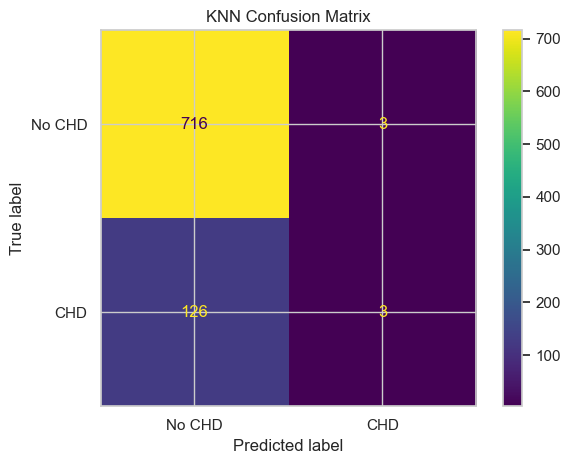

In [39]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn_test_predictions,
    display_labels=["No CHD", "CHD"]
)

plt.title("KNN Confusion Matrix")
plt.tight_layout()

plt.savefig(
    figures_folder /
    "knn_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Plot KNN performance by number of neighbors

In [40]:
knn_plot_data = knn_cv_results[
    (
        knn_cv_results["param_weights"] ==
        "uniform"
    )
    &
    (
        knn_cv_results["param_metric"] ==
        "euclidean"
    )
].copy()

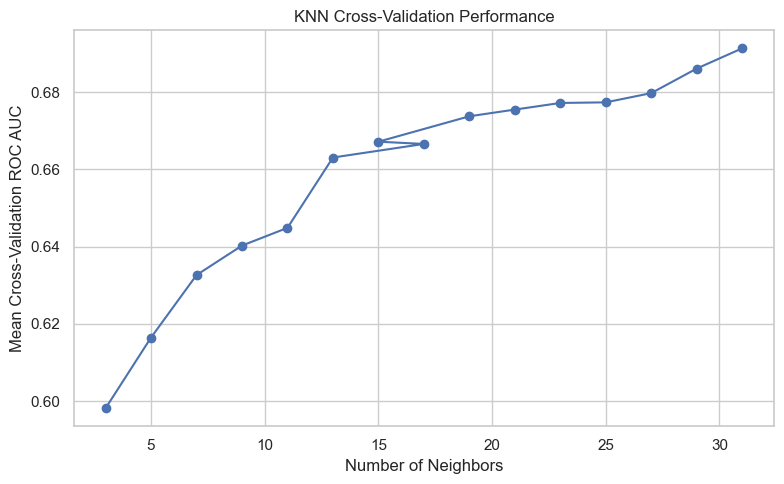

In [41]:
plt.figure(figsize=(8, 5))

plt.plot(
    knn_plot_data["param_n_neighbors"],
    knn_plot_data["mean_test_score"],
    marker="o"
)

plt.title("KNN Cross-Validation Performance")
plt.xlabel("Number of Neighbors")
plt.ylabel("Mean Cross-Validation ROC AUC")
plt.tight_layout()

plt.savefig(
    figures_folder /
    "knn_neighbors_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Save the best KNN model

In [42]:
joblib.dump(
    best_knn_model,
    models_folder / "knn_model.joblib"
)

['../results/models/knn_model.joblib']

# ROC Curves

### Calculate ROC Curves

In [43]:
linear_fpr, linear_tpr, _ = roc_curve(
    y_test,
    linear_test_predictions
)

logistic_fpr, logistic_tpr, _ = roc_curve(
    y_test,
    logistic_test_probabilities
)

knn_fpr, knn_tpr, _ = roc_curve(
    y_test,
    knn_test_probabilities
)

### Plot model ROC curves

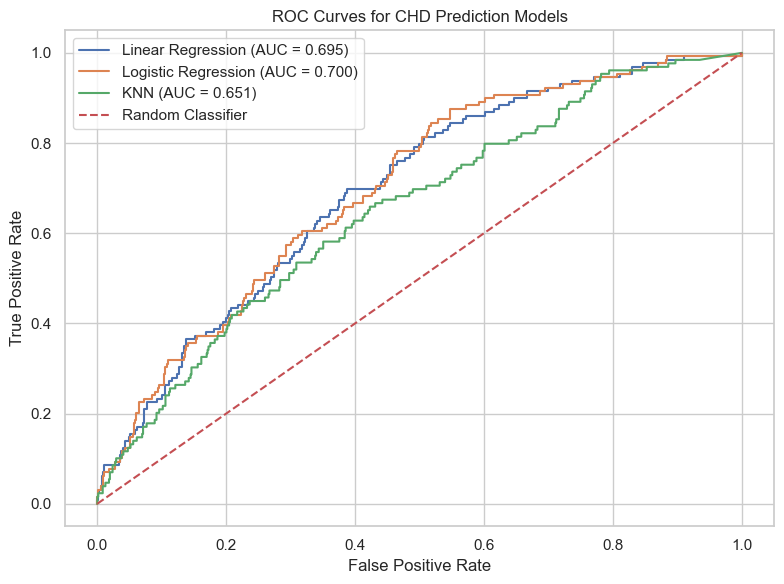

In [44]:
plt.figure(figsize=(8, 6))

plt.plot(
    linear_fpr,
    linear_tpr,
    label=(
        "Linear Regression "
        f"(AUC = {linear_classification_metrics['ROC AUC']:.3f})"
    )
)

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label=(
        "Logistic Regression "
        f"(AUC = {logistic_metrics['ROC AUC']:.3f})"
    )
)

plt.plot(
    knn_fpr,
    knn_tpr,
    label=(
        "KNN "
        f"(AUC = {knn_metrics['ROC AUC']:.3f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curves for CHD Prediction Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()

plt.savefig(
    figures_folder /
    "model_roc_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Save predictions and metrics

### Create prediction table

In [45]:
predictions = pd.DataFrame({
    "Actual": y_test,
    "Linear_Predicted_Value":
        linear_test_predictions,
    "Linear_Predicted_Class":
        linear_test_classes,
    "Logistic_Probability":
        logistic_test_probabilities,
    "Logistic_Predicted_Class":
        logistic_test_predictions,
    "KNN_Probability":
        knn_test_probabilities,
    "KNN_Predicted_Class":
        knn_test_predictions
})

predictions.head()

,Actual,Linear_Predicted_Value,Linear_Predicted_Class,Logistic_Probability,Logistic_Predicted_Class,KNN_Probability,KNN_Predicted_Class
0,0,0.205354,0,0.195314,0,0.176500,0
1,0,0.231530,0,0.215267,0,0.196381,0
2,1,0.222698,0,0.201414,0,0.282583,0
3,0,0.444408,0,0.524433,1,0.304556,0
4,0,0.220795,0,0.209047,0,0.098704,0


### Save predictions

In [46]:
predictions.to_csv(
    predictions_folder /
    "model_predictions.csv",
    index=False
)

### Create model metrics table

In [47]:
classification_metrics = pd.DataFrame(
    [
        linear_classification_metrics,
        logistic_metrics,
        knn_metrics
    ]
)

classification_metrics

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Linear Regression,0.850236,0.666667,0.031008,0.059259,0.695195
1,Logistic Regression,0.849057,0.529412,0.069767,0.123288,0.699637
2,KNN,0.847877,0.500000,0.023256,0.044444,0.651077


### Round metrics

In [48]:
classification_metrics_rounded = (
    classification_metrics.copy()
)

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC AUC"
]

classification_metrics_rounded[
    metric_columns
] = classification_metrics_rounded[
    metric_columns
].round(4)

classification_metrics_rounded

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Linear Regression,0.8502,0.6667,0.0310,0.0593,0.6952
1,Logistic Regression,0.8491,0.5294,0.0698,0.1233,0.6996
2,KNN,0.8479,0.5000,0.0233,0.0444,0.6511


### Save model metrics

In [49]:
classification_metrics_rounded.to_csv(
    results_folder /
    "classification_metrics.csv",
    index=False
)

In [50]:
pd.DataFrame(
    [linear_regression_metrics]
).to_csv(
    results_folder /
    "linear_regression_metrics.csv",
    index=False
)

### Compare training and testing accuracy

In [51]:
training_testing_accuracy = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Logistic Regression",
        "KNN"
    ],
    "Training Accuracy": [
        accuracy_score(
            y_train,
            linear_train_classes
        ),
        accuracy_score(
            y_train,
            logistic_train_predictions
        ),
        accuracy_score(
            y_train,
            best_knn_model.predict(
                X_train_standard
            )
        )
    ],
    "Testing Accuracy": [
        accuracy_score(
            y_test,
            linear_test_classes
        ),
        accuracy_score(
            y_test,
            logistic_test_predictions
        ),
        accuracy_score(
            y_test,
            knn_test_predictions
        )
    ]
})

training_testing_accuracy.round(4)

,Model,Training Accuracy,Testing Accuracy
0,Linear Regression,0.8531,0.8502
1,Logistic Regression,0.8572,0.8491
2,KNN,1.0000,0.8479


### Save train-test comparison

In [52]:
training_testing_accuracy.to_csv(
    results_folder /
    "training_testing_accuracy.csv",
    index=False
)

### Confirm saved results

In [53]:
print("Saved models:")

for file in sorted(
    models_folder.iterdir()
):
    print("-", file.name)

Saved models:
- knn_model.joblib
- linear_regression_model.joblib
- logistic_regression_model.joblib


In [54]:
print("\nSaved results:")

for file in sorted(
    results_folder.glob("*.csv")
):
    print("-", file.name)


Saved results:
- best_knn_summary.csv
- best_model_by_metric.csv
- classification_metrics.csv
- confusion_matrix_results.csv
- final_model_comparison.csv
- knn_grid_search_results.csv
- linear_regression_metrics.csv
- logistic_regression_coefficients.csv
- ranked_model_metrics.csv
- training_testing_accuracy.csv


In [55]:
print("\nSaved figures:")

for file in sorted(
    figures_folder.iterdir()
):
    print("-", file.name)


Saved figures:
- .DS_Store
- knn_confusion_matrix.png
- knn_neighbors_performance.png
- linear_regression_confusion_matrix.png
- logistic_regression_coefficients.png
- logistic_regression_confusion_matrix.png
- model_comparison
- model_roc_curves.png
